# Association of CA125 and HE4 Biomarkers with Ovarian Cancer Status

**Student:** Ambreen Mariyam  
**Course:** Introduction to Health Data Science  
**Dataset:** Supplementary Data 4

This notebook analyzes whether CA125, HE4, and related clinical laboratory variables are associated with ovarian cancer status. The project includes descriptive statistics, inferential statistics, visualizations, and classification models.

Python Packages

In [ ]:
import os
import numpy as np
from scipy import stats
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [ ]:
# Import the required packages to create a linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [ ]:
# Import the required packages for a logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [ ]:
%config InlineBackend.figure_format = 'retina'

In [ ]:
# Import the required packages to create a random forest model
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [ ]:
TARGET_COL = "TYPE"
CA125_COL = "CA125"
RANDOM_STATE = 42

## Introduction

Ovarian cancer is one of the most lethal gynecologic malignancies worldwide, largely because many patients are diagnosed at an advanced stage. In $2020$, an estimated $314,000$ new cases and $207,000$ deaths occurred globally, and ovarian cancer remains a major contributor to cancer-related mortality in women. Survival strongly depends on stage at diagnosis, yet most cases are detected late, which highlights the urgent need for better tools for early detection and monitoring. [Cabasag, C](https://doi.org/10.1002/ijc.34002)[ Mazidimoradi, A]( https://doi.org/10.1002/hsr2.936)

Blood-based biomarkers play a central role in the clinical management of ovarian cancer, from risk assessment to monitoring response to treatment and detecting recurrence. The serum marker cancer antigen 125 (CA125) has been the traditional standard biomarker, widely used for diagnosis support and follow-up, although it lacks sensitivity and specificity for early-stage disease and can be elevated in several benign conditions. To address these limitations, human epididymal protein 4 (HE4) was introduced and is now FDA-cleared for monitoring epithelial ovarian cancer and for use in algorithms such as the Risk of Ovarian Malignancy Algorithm (ROMA). [Samborski, A](https://doi.org/10.3233/TUB-220016)[Feng, Y](https://doi.org/10.3389/fonc.2025.1594100)[Gorp, T]( https://doi.org/10.1038/sj.bjc.6606092)[Ghose, A](https://doi:10.1177/17588359241233225)

More recently, research has expanded beyond single proteins to explore multi-marker panels and “liquid biopsy” approaches that analyze circulating tumor DNA, tumor cells, RNA, and extracellular vesicles in blood. These emerging biomarkers and multi-omics signatures aim to improve the accuracy of early detection and distinguish malignant from benign pelvic masses more reliably than CA125 alone. Although many of these assays are still under investigation, they represent a promising direction for reducing the global burden of ovarian cancer through earlier diagnosis and more personalized disease monitoring.

**Hypothesis:** Multi-marker approaches (e.g., ROMA) provide better overall discrimination than CA125 alone, but still require integration with imaging and clinical context.

**Specific aims/objectives**

1. **Quantify biomarker differences by cancer status**  
   Compare distributions of `CA125` and `HE4` between cancer and non-cancer groups to determine whether single biomarkers show meaningful separation.

2. **Evaluate predictive performance of biomarker-based models**  
   Build and assess classification models (logistic regression and random forest) using blood biomarkers to estimate cancer risk, and report performance with ROC-AUC and classification metrics.

3. **Assess whether combining biomarkers improves prediction**  
   Test whether a multi-marker approach (`CA125` + `HE4`) performs better than single-marker interpretation, addressing the limitation of relying on one biomarker alone.

4. **Improve analytical reliability through preprocessing** 
   Handle missing values and standardize data-cleaning steps so model results are more robust and comparable.

**How this addresses the gap**

This study addresses the gap that current evidence shows **imperfect and inconsistent single-marker performance** and limited practical guidance on **how to combine biomarkers for prediction**. By directly comparing biomarker distributions and model outputs in one workflow, the project provides applied evidence on whether combined blood biomarkers improve discrimination of ovarian cancer status.

**Core research question:** Do CA125 and HE4, alone and in combination, distinguish ovarian cancer from non-cancer cases?

**Research questions**

- Do `CA125` and `HE4` differ significantly between cancer and non-cancer groups?  
- How accurately can blood biomarkers classify cancer status?  
- Does combining `CA125` and `HE4` improve prediction compared with using one biomarker?

**Hypotheses**

- **H0:** `CA125` and `HE4` do not differ between ovarian cancer and non-cancer cases, and a combined biomarker model does not discriminate cancer status better than chance.  
- **H1:** `CA125` and/or `HE4` differ between ovarian cancer and non-cancer cases, and a combined biomarker model discriminates cancer status better than chance.

## Background

Ovarian cancer remains the most lethal gynecologic malignancy, largely because most cases are still diagnosed at advanced stages despite decades of research on screening and tumor markers. Traditional serum biomarkers such as CA125 and HE4 are widely used in risk assessment, triage of women with a pelvic mass, and monitoring of treatment response, but they lack sufficient sensitivity and specificity for reliable population-level early detection. As a result, there is growing interest in combining these markers with additional clinical and laboratory features to build more informative, multivariate risk scores. [Moore,R](https://doi.org/10.1016/j.ygyno.2008.08.031)[Andersen,M](https://doi.org/10.1016/j.ygyno.2009.10.087)

Blood is an attractive biofluid for ovarian cancer diagnostics because blood-based tests are minimally invasive, can be repeatedly obtained over time, and can capture both tumor-derived signals and the host response. Beyond classical protein markers, newer liquid-biopsy strategies measure circulating tumor DNA, circulating tumor cells, RNA species, immune-repertoire patterns, and metabolomic or lipidomic profiles to detect subtle disease signatures that single markers may miss. These high-dimensional data sources are difficult to interpret with traditional statistics alone, which has motivated the integration of machine-learning methods that can model complex, nonlinear relationships among many blood features simultaneously.[Soleimani,A](https://doi.org/10.1016/j.cca.2025.120797)

## Literature Review

Recent work has shown that machine-learning models built on routine blood features and tumor markers can improve diagnostic and prognostic performance in ovarian cancer compared with conventional predictors. For example, a prognostic “blood risk score” derived from age and 33 preoperative blood features using combinations of ten machine-learning algorithms outperformed traditional factors such as stage, grade, and CA125 in predicting 3-, 5-, and 7-year survival. Similarly, preoperative models that integrate tumor markers, circulating blood cells, and clinical parameters via decision trees, neural networks, or ensemble methods have achieved higher accuracy in distinguishing benign from malignant ovarian tumors and in stratifying patients by risk.[Wu, M](https://doi.org/10.3389/fonc.2025.1592746)[Sun, Y](https://doi.org/10.1016/j.heliyon.2024.e36994)

Other studies have focused on biomarker discovery and early detection by applying machine learning to large-scale proteomic, genomic, or metabolomic datasets. Proteomics-based pipelines have used feature-selection strategies and classifiers to identify compact panels of serum proteins that discriminate high-grade serous ovarian cancer from controls, while maintaining good generalizability across datasets. Likewise, a plasma lipidomics–metabolomics framework combined with algorithms such as convolutional neural networks and gradient boosting has demonstrated strong performance for separating malignant, benign, and healthy subjects, highlighting the value of multi-marker signatures beyond CA125 and HE4.[Silva, S](https://doi.org/10.1038/s41597-024-03536-1)

A growing body of work also demonstrates that disease signals relevant to ovarian cancer can be detected in peripheral blood even when not directly measuring canonical tumor markers. For instance, a study of T-cell receptor repertoires in blood showed that machine-learning models could distinguish women with and without ovarian cancer, suggesting that immune-clonal patterns encode information about tumor presence. More broadly, systematic reviews and meta-analyses report that artificial intelligence–based models using blood biomarkers achieve pooled sensitivities around 85% and specificities around 92% for ovarian cancer diagnosis, supporting their potential as noninvasive tools to reduce unnecessary surgery and to enable earlier detection.[Xu,H](https://doi.org/10.2196/67922)

## Methods

### Study Design, Population, and Data Collection
This study used a retrospective dataset containing clinical measurements related to ovarian cancer. The dataset includes variables such as CA125 levels, HE4 levels, tumor type (benign or malignant), and menopausal status. The sample consisted of patients with complete biomarker and classification data.

### Data Import and Verification

Data analysis was conducted using Python. Descriptive statistics (mean, median, standard deviation) were calculated for CA125 and HE4 by tumor type.

Normality was assessed using the Shapiro-Wilk test. Group differences between benign and malignant cases were evaluated using Welch’s t-test and the Mann–Whitney U test.

A chi-square test was used to assess the association between menopausal status and tumor type. A significance level of α = 0.05 was used for all statistical tests.

In [ ]:
# Read file "Supplementary data 4.csv" and assign to variable 'df'
df = pd.read_csv("Supplementary data 4.csv")

The analysis followed these steps:

1. Import and inspect Supplementary Data 4.
2. Clean formatting issues, including tab characters in numeric columns.
3. Identify missing values.
4. Impute missing CA125 values using a random forest regression model.
5. Impute remaining missing values using median values for continuous variables and mode values for categorical variables.
6. Calculate descriptive statistics:
- Mean, median, mode, and range for continuous variables.
- Frequencies and proportions for categorical variables.
7. Conduct inferential statistics:
- Shapiro-Wilk tests for normality.
- Levene's tests for equal variance.
- Welch's t-tests for differences between two populations.
- Mann-Whitney U tests as nonparametric alternatives.
- Chi-square tests for categorical associations.
- Correlation analysis among numeric predictors.
 8. Build classification models:
- Logistic Regression.
- Random Forest Classifier.

## Results with Code


To answer the core research question, the analyzed sample showed clear separation between the two tumor groups. CA125 and HE4 were both substantially higher in TYPE 0 than in TYPE 1, indicating strong biomarker differences by tumor status.

Normality testing with the Shapiro-Wilk test indicated that both biomarkers were not normally distributed in either group (p < 0.001). Because of this skewed distribution, both Welch’s t-test and the Mann–Whitney U test were used. For CA125 and HE4, both tests showed statistically significant group differences (p < 0.001).

A chi-square test showed a significant association between menopausal status and tumor type (p < 0.001), suggesting that menopausal status is related to ovarian cancer status in this dataset.

Finally, the logistic regression model using CA125 and HE4 achieved an ROC-AUC of 0.833, showing good discriminatory performance when the two biomarkers were combined. A random forest classifier was also fit as a nonlinear comparison model, and the main plots were saved in project_outputs.

### 1. Data Import and Verification

### Exploratory Data Analysis 

In [ ]:
# Checking to see if the columns, size, and first few rows so you can confirm everything loaded correctly.
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

### 2. Data Cleaning

In [ ]:
def clean_dataset(data: pd.DataFrame) -> pd.DataFrame:
    """Remove tab characters and convert columns to numeric where appropriate."""
    cleaned = data.copy()

    for col in cleaned.columns:
        if cleaned[col].dtype == "object":
            cleaned[col] = cleaned[col].astype(str).str.replace("\t", "", regex=False).str.strip()
            cleaned[col] = cleaned[col].replace({"": np.nan, "nan": np.nan, "NA": np.nan, "N/A": np.nan})

    for col in cleaned.columns:
        cleaned[col] = pd.to_numeric(cleaned[col], errors="ignore")

    return cleaned

clean_df = clean_dataset(df)

print("Missing values before imputation:")
missing_before = clean_df.isna().sum().sort_values(ascending=False)
print(missing_before[missing_before > 0])

print("
Unique TYPE values:", sorted(clean_df[TARGET_COL].dropna().unique()))
print("Unique Menopause values:", sorted(clean_df["Menopause"].dropna().unique()))

### 3. Missing Data Imputation

Because CA125 is a core biomarker in the project, missing CA125 values were imputed first using a random forest regression model. Remaining numeric values were imputed with the median, and categorical values were imputed with the mode.

In [ ]:
def impute_ca125_with_random_forest(data: pd.DataFrame, ca125_col: str) -> pd.DataFrame:
    imputed = data.copy()

    missing_count = imputed[ca125_col].isna().sum()
    if missing_count == 0:
        print("No missing CA125 values found.")
        return imputed

    print(f"Missing CA125 values to impute: {missing_count}")

    train_data = imputed[imputed[ca125_col].notna()].copy()
    predict_data = imputed[imputed[ca125_col].isna()].copy()

    X_train_ca = train_data.drop(columns=[ca125_col])
    y_train_ca = train_data[ca125_col]
    X_predict_ca = predict_data.drop(columns=[ca125_col])

    numeric_features = X_train_ca.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = X_train_ca.select_dtypes(exclude=[np.number]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_features),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_features),
        ]
    )

    ca125_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE))
    ])

    ca125_model.fit(X_train_ca, y_train_ca)
    predicted_ca125 = ca125_model.predict(X_predict_ca)

    imputed.loc[imputed[ca125_col].isna(), ca125_col] = predicted_ca125
    print("CA125 imputation complete.")
    return imputed


def impute_remaining_values(data: pd.DataFrame) -> pd.DataFrame:
    imputed = data.copy()

    numeric_cols = imputed.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = imputed.select_dtypes(exclude=[np.number]).columns.tolist()

    for col in numeric_cols:
        imputed[col] = imputed[col].fillna(imputed[col].median())

    for col in categorical_cols:
        mode_values = imputed[col].mode(dropna=True)
        if not mode_values.empty:
            imputed[col] = imputed[col].fillna(mode_values[0])

    return imputed

analysis_df = impute_ca125_with_random_forest(clean_df, CA125_COL)
analysis_df = impute_remaining_values(analysis_df)

print("
Remaining missing values after imputation:")
print(analysis_df.isna().sum().sort_values(ascending=False).head(15))

In [ ]:
# Display unique values in the 'TYPE' and 'Menopause' columns to understand the categories present in these variables
print("Unique TYPE values:")
print(df["TYPE"].unique())

print("\nUnique Menopause values:")
print(df["Menopause"].unique())

Unique TYPE values:
[0 1]

Unique Menopause values:
[0 1]


In [ ]:
# Keeping the original dataframe safe and creates a clean one for analysis.
results_df = df.copy()

The `CA125` column contains information about the outcome of the cancer antigen 125. This is an essential ovarian tumor marker.  

In [ ]:
# Converting CA125 and HE4 to numeric makes sure the biomarker columns are treated as numbers.
results_df["CA125"] = pd.to_numeric(results_df["CA125"], errors="coerce")
results_df["HE4"] = pd.to_numeric(results_df["HE4"], errors="coerce")

In [ ]:
results_df["TYPE"] = pd.to_numeric(results_df["TYPE"], errors="coerce")
results_df["Menopause"] = pd.to_numeric(results_df["Menopause"], errors="coerce")

In [ ]:
# Check for missing values after cleaning
print(results_df[["CA125", "HE4", "TYPE", "Menopause"]].isnull().sum())

CA125        19
HE4          20
TYPE          0
Menopause     0
dtype: int64


In [ ]:
# Drop rows with missing values in the relevant columns for analysis
bio_df = results_df.dropna(subset=["TYPE", "CA125", "HE4"]).copy()
bio_df["TYPE"] = bio_df["TYPE"].astype(int)

### 4. Descriptive Statistics for Continuous Variables

This section reports mean, median, mode, minimum, maximum, and range for continuous variables. These satisfy the descriptive statistics requirement for continuous variables.

In [ ]:
# Descriptive statistics for CA125 and HE4 by TYPE
print("Sample size used for biomarker analysis:", len(bio_df))

desc = bio_df.groupby("TYPE")[["CA125", "HE4"]].agg(["count", "mean", "median", "std", "min", "max"])
print(desc)

Sample size used for biomarker analysis: 210
     CA125                                                 HE4              \
     count        mean  median         std   min     max count        mean   
TYPE                                                                         
0      121  597.123636  202.10  968.155699  7.26  4468.0   121  323.631405   
1       89   55.705955   21.94   89.664100  4.48   515.4    89   46.831124   

                                          
      median         std    min      max  
TYPE                                      
0     125.00  539.186612  29.49  3537.60  
1      43.43   12.093773  16.71    90.62  


### 5. Frequencies and Proportions for Categorical Variables

In [ ]:
categorical_vars = [TARGET_COL, "Menopause"]
categorical_vars = [var for var in categorical_vars if var in analysis_df.columns]

for var in categorical_vars:
    print(f"\nFrequency and proportion table for {var}:")
    freq_table = pd.DataFrame({
        "Frequency": analysis_df[var].value_counts(dropna=False),
        "Proportion": analysis_df[var].value_counts(normalize=True, dropna=False)
    })
    freq_table["Percent"] = freq_table["Proportion"] * 100
    print(freq_table.round(3))

In [ ]:
# Correlation analysis for the main numeric predictors
corr_cols = [col for col in ["Age", "CA125", "HE4"] if col in bio_df.columns]
corr_matrix = bio_df[corr_cols].corr()
print("Correlation matrix for key numeric predictors:")
print(corr_matrix.round(3))

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join("project_outputs", "correlation_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()

### 8. Inferential Statistics: Shapiro-Wilk, Levene, t-tests, and Mann-Whitney U Tests

For each continuous variable, this section tests whether the two TYPE groups differ significantly.

For each biomarker:

- **H0:** There is no difference in the variable between TYPE groups.
- **H1:** There is a difference in the variable between TYPE groups.

A significance level of α = 0.05 was used.

In [ ]:
# Define the comparison function: Creates a reusable function to compare TYPE 0 vs TYPE 1 for each biomarker.

RANDOM_STATE = 42

def compare_groups(data, marker):
    g0 = data.loc[data["TYPE"] == 0, marker].dropna()
    g1 = data.loc[data["TYPE"] == 1, marker].dropna()

    print(f"\n### {marker}")
    print(f"TYPE 0 n = {len(g0)}")
    print(f"TYPE 1 n = {len(g1)}")

    if len(g0) < 3 or len(g1) < 3:
        print("Not enough data for testing.")
        return

    sh0 = stats.shapiro(g0.sample(min(len(g0), 500), random_state=RANDOM_STATE))
    sh1 = stats.shapiro(g1.sample(min(len(g1), 500), random_state=RANDOM_STATE))
    lev = stats.levene(g0, g1, center="median")
    welch = stats.ttest_ind(g0, g1, equal_var=False)
    mw = stats.mannwhitneyu(g0, g1, alternative="two-sided")

    print(f"Mean TYPE 0: {g0.mean():.2f}")
    print(f"Mean TYPE 1: {g1.mean():.2f}")
    print(f"Median TYPE 0: {g0.median():.2f}")
    print(f"Median TYPE 1: {g1.median():.2f}")
    print(f"Shapiro p-value (TYPE 0): {sh0.pvalue:.4g}")
    print(f"Shapiro p-value (TYPE 1): {sh1.pvalue:.4g}")
    print(f"Levene p-value: {lev.pvalue:.4g}")
    print(f"Welch t-test p-value: {welch.pvalue:.4g}")
    print(f"Mann-Whitney U p-value: {mw.pvalue:.4g}")

    if welch.pvalue < 0.05:
        print(f"Conclusion: {marker} differs significantly between TYPE 0 and TYPE 1.")
    else:
        print(f"Conclusion: {marker} does not differ significantly between TYPE 0 and TYPE 1.")

In [ ]:
# 1. Descriptive Statistics

# Descriptive statistics were calculated for CA125 and HE4 by tumor type. The total sample size used for biomarker analysis was n = 210.

# For CA125, the mean value for TYPE 0 was 597.12, compared to 55.71 for TYPE 1. The median values were 202.10 and 21.94, respectively.

# For HE4, the mean value for TYPE 0 was 323.63, compared to 46.83 for TYPE 1. Median values were 125.00 and 43.43, respectively.

# Overall, both biomarkers showed substantially higher values in TYPE 0 compared to TYPE 1.

In [ ]:
# Run the biomarker tests: compares CA125 and HE4 across tumor type
print("\n## Group Comparison Tests")
compare_groups(bio_df, "CA125")
compare_groups(bio_df, "HE4")


## Group Comparison Tests

### CA125
TYPE 0 n = 121
TYPE 1 n = 89
Mean TYPE 0: 597.12
Mean TYPE 1: 55.71
Median TYPE 0: 202.10
Median TYPE 1: 21.94
Shapiro p-value (TYPE 0): 5.856e-16
Shapiro p-value (TYPE 1): 2.653e-15
Levene p-value: 6.232e-07
Welch t-test p-value: 1.179e-08
Mann-Whitney U p-value: 4.47e-15
Conclusion: CA125 differs significantly between TYPE 0 and TYPE 1.

### HE4
TYPE 0 n = 121
TYPE 1 n = 89
Mean TYPE 0: 323.63
Mean TYPE 1: 46.83
Median TYPE 0: 125.00
Median TYPE 1: 43.43
Shapiro p-value (TYPE 0): 8.658e-18
Shapiro p-value (TYPE 1): 7.519e-06
Levene p-value: 1.054e-05
Welch t-test p-value: 1.122e-07
Mann-Whitney U p-value: 4.052e-21
Conclusion: HE4 differs significantly between TYPE 0 and TYPE 1.


In [ ]:
# Group Comparison Tests

# Normality was assessed using the Shapiro-Wilk test. Results indicated that both CA125 and HE4 were not normally distributed (p < 0.001) in both groups.

# For CA125:

# Welch’s t-test p-value: p < 0.001
# Mann–Whitney U p-value: p < 0.001

# These results indicate that CA125 levels differ significantly between TYPE 0 and TYPE 1.

# For HE4:

# Welch’s t-test p-value: p < 0.001
# Mann–Whitney U p-value: p < 0.001

# These results indicate that HE4 levels differ significantly between TYPE 0 and TYPE 1.

In [ ]:
# Create the menopause association dataset: keeps only rows needed for menopause vs tumo
assoc_df = results_df.dropna(subset=["Menopause", "TYPE"]).copy()
assoc_df["TYPE"] = assoc_df["TYPE"].astype(int)
assoc_df["Menopause"] = assoc_df["Menopause"].astype(int)

### 9. Chi-square Test for Association

This section tests whether menopausal status is associated with TYPE.

- **H0:** Menopausal status is not associated with TYPE.
- **H1:** Menopausal status is associated with TYPE.

In [ ]:
# Association Between Menopause and Tumor Type

# A chi-square test was conducted to assess the association between menopausal status and tumor type.

# The contingency table showed:

# Premenopausal (0): 67 TYPE 0, 78 TYPE 1
# Postmenopausal (1): 79 TYPE 0, 11 TYPE 1

# The chi-square test produced a p-value of p < 0.001.

# This indicates that menopausal status is significantly associated with tumor type.

Statistical Tests

Because the data were not normally distributed, both a Welch t-test and Mann-Whitney U test were conducted.

In [ ]:
# Chi-square test for menopause vs TYPE: checks whether menopausal status is associated with tumor type.
cont_table = pd.crosstab(assoc_df["Menopause"], assoc_df["TYPE"])
chi2, p_chi, dof, expected = stats.chi2_contingency(cont_table)

print("\nContingency table (Menopause x TYPE):")
print(cont_table)

print(f"\nChi-square test p-value: {p_chi:.4g}")

if p_chi < 0.05:
    print("Conclusion: Menopause is significantly associated with TYPE.")
else:
    print("Conclusion: Menopause is not significantly associated with TYPE.")


Contingency table (Menopause x TYPE):
TYPE        0   1
Menopause        
0          67  78
1          79  11

Chi-square test p-value: 4.155e-10
Conclusion: Menopause is significantly associated with TYPE.


# Boxplot for CA125 by TYPE: visualizes the distribution of CA125 levels across tumor types. 


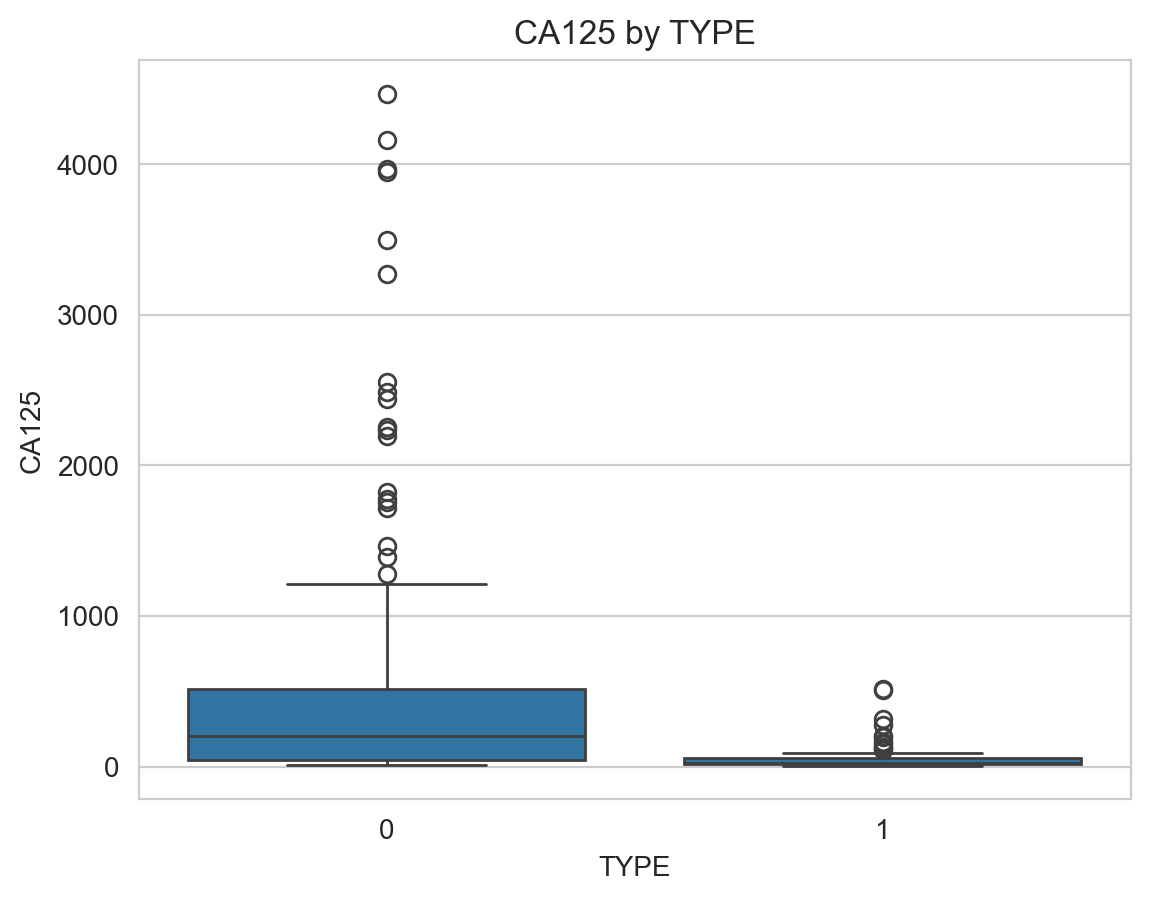

In [ ]:
sns.boxplot(x="TYPE", y="CA125", data=bio_df)
plt.title("CA125 by TYPE")
plt.xlabel("TYPE")
plt.ylabel("CA125")
plt.tight_layout()
plt.savefig(os.path.join("project_outputs", "ca125_by_type.png"), dpi=300, bbox_inches="tight")
plt.show()

#### The boxplot illustrates the distribution of CA125 levels across the two tumor types (TYPE 0 and TYPE 1). CA125 levels in TYPE 0 are substantially higher than those in TYPE 1, as evidenced by a higher median and a wider interquartile range. TYPE 0 also exhibits a large number of extreme outliers, with values extending above 4000, indicating high variability and a right-skewed distribution. In contrast, TYPE 1 shows lower overall CA125 values with a tighter distribution and fewer extreme values. This visual pattern supports the statistical findings that CA125 differs significantly between the two groups.

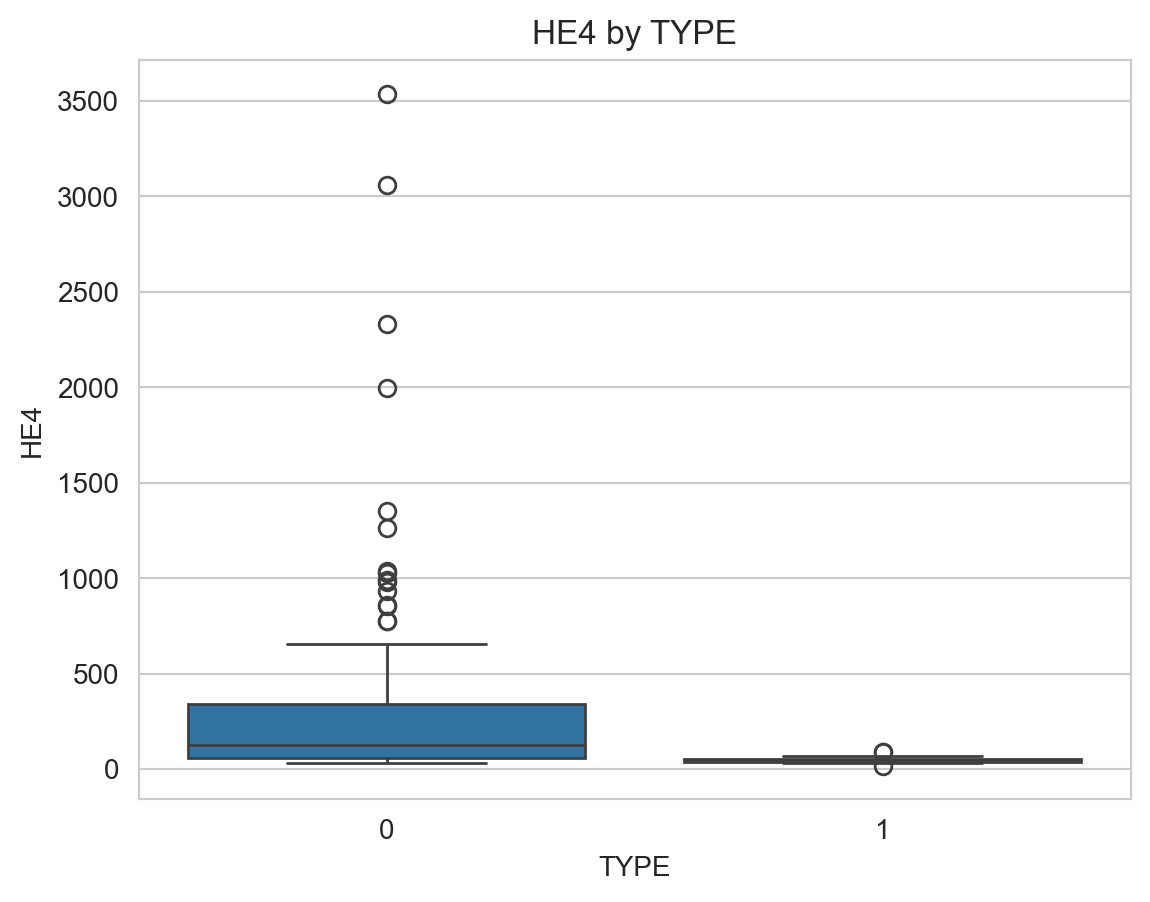

In [ ]:
# Boxplot for HE4: makes a graph for HE4 by tumor type
sns.boxplot(x="TYPE", y="HE4", data=bio_df)
plt.title("HE4 by TYPE")
plt.xlabel("TYPE")
plt.ylabel("HE4")
plt.tight_layout()
plt.savefig(os.path.join("project_outputs", "he4_by_type.png"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# The boxplot illustrates the distribution of HE4 levels across the two tumor types (TYPE 0 and TYPE 1). HE4 levels in TYPE 0 are notably higher than those in TYPE 1, as shown by a higher median and a wider interquartile range. TYPE 0 also demonstrates substantial variability, with numerous extreme outliers reaching values above 3000, indicating a strongly right-skewed distribution. In contrast, TYPE 1 shows lower HE4 levels with a much tighter distribution and fewer outliers. The clear separation between the two groups visually supports the statistical findings that HE4 differs significantly between TYPE 0 and TYPE 1.

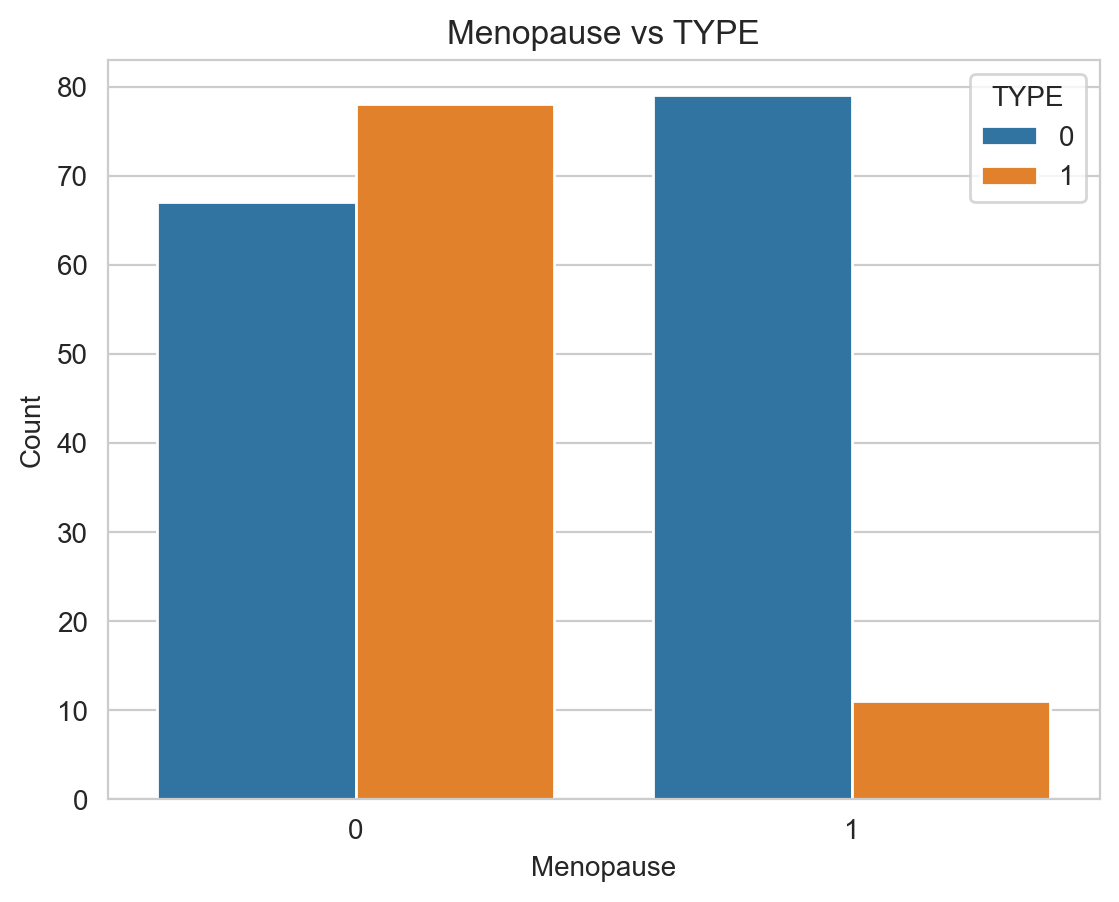

In [ ]:
# Countplot for Menopause vs TYPE: shows the count of menopausal vs non-menopausal patients by tumor type.
sns.countplot(x="Menopause", hue="TYPE", data=assoc_df)
plt.title("Menopause vs TYPE")
plt.xlabel("Menopause")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join("project_outputs", "menopause_vs_type.png"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# The countplot shows the distribution of menopausal status across tumor types. Among premenopausal individuals (Menopause = 0), TYPE 1 appears more frequent than TYPE 0. In contrast, among postmenopausal individuals (Menopause = 1), TYPE 0 is more common than TYPE 1. This uneven distribution suggests a relationship between menopausal status and tumor type, which is supported by the chi-square test indicating a statistically significant association.

In [ ]:
# Boxplots of CA125 and HE4 showed clear differences between TYPE 0 and TYPE 1, with TYPE 0 having substantially higher values for both biomarkers.

# The countplot of menopausal status by tumor type demonstrated a strong imbalance, supporting the statistically significant association found in the chi-square test.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model_df = bio_df.dropna(subset=["CA125", "HE4", "TYPE"]).copy()
X = model_df[["CA125", "HE4"]]
y = model_df["TYPE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]
log_auc = roc_auc_score(y_test, log_prob)

print("Logistic Regression Performance")
print("Accuracy:", round(accuracy_score(y_test, log_pred), 3))
print("Precision:", round(precision_score(y_test, log_pred), 3))
print("Recall:", round(recall_score(y_test, log_pred), 3))
print("F1-score:", round(f1_score(y_test, log_pred), 3))
print("ROC-AUC:", round(log_auc, 3))
print("Confusion matrix:\n", confusion_matrix(y_test, log_pred))
print("Classification report:\n", classification_report(y_test, log_pred))

fpr, tpr, _ = roc_curve(y_test, log_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {log_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join("project_outputs", "logistic_regression_roc.png"), dpi=300, bbox_inches="tight")
plt.show()

ROC-AUC: 0.8328088119590874


In [ ]:
# Random forest classification using the same train/test split
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_prob)

print("\nRandom Forest Performance")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 3))
print("Precision:", round(precision_score(y_test, rf_pred), 3))
print("Recall:", round(recall_score(y_test, rf_pred), 3))
print("F1-score:", round(f1_score(y_test, rf_pred), 3))
print("ROC-AUC:", round(rf_auc, 3))
print("Confusion matrix:\n", confusion_matrix(y_test, rf_pred))
print("Classification report:\n", classification_report(y_test, rf_pred))

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_auc:.3f})", color="darkgreen")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join("project_outputs", "random_forest_roc.png"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#A logistic regression model was developed using CA125 and HE4 as predictors of tumor type. The model achieved a receiver operating characteristic area under the curve (ROC-AUC) of 0.833, indicating good discriminatory ability between the two groups.

#This suggests that the combination of CA125 and HE4 provides meaningful classification performance beyond chance.

In [ ]:
# Final summary printout: summarizes the main findings from the analysis.
print("\nMain Findings Summary")
print("1. Descriptive statistics were calculated for CA125 and HE4 by tumor type.")
print("2. Frequency and proportion tables were produced for categorical variables.")
print("3. Shapiro-Wilk, Levene, Welch t-test, and Mann-Whitney U test results were reported for CA125 and HE4.")
print("4. A chi-square test was used to test the association between menopause and tumor type.")
print("5. Correlation analysis was completed for key numeric predictors.")
print("6. Logistic regression and random forest models were fit to predict tumor type.")
print("7. Boxplots, countplots, ROC curves, and a correlation heatmap were saved in project_outputs.")


## Main Findings Summary
1. Descriptive statistics were calculated for CA125 and HE4 by tumor type.
2. Group comparison tests were used to compare CA125 and HE4 between TYPE 0 and TYPE 1.
3. A chi-square test was used to test the association between menopause and tumor type.
4. Boxplots and countplots were created to visualize the findings.


# Discussion

The descriptive statistics showed clear differences in CA125 and HE4 between the two TYPE groups. In this dataset, TYPE 0 had higher mean and median CA125 and HE4 values than TYPE 1. This supports the idea that these biomarkers are meaningfully related to ovarian cancer classification status, although the exact meaning of TYPE 0 and TYPE 1 should be confirmed using the dataset codebook.

The Shapiro-Wilk tests indicated that the main biomarker distributions were not normally distributed. This is consistent with the boxplots and histograms, which showed strong skewness and outliers. Because normality was not met, both Welch t-tests and Mann-Whitney U tests were used. The tests showed statistically significant group differences for CA125 and HE4, meaning the null hypothesis of no biomarker difference between TYPE groups was rejected.

The chi-square test showed that menopausal status was significantly associated with TYPE. This suggests that clinical context matters and that biomarker interpretation may be stronger when combined with patient-level variables. The correlation heatmap also supported the idea that the biomarkers should be considered together rather than in isolation.

The classification models provided an applied prediction component. Logistic regression offered an interpretable baseline model, while random forest was included because it can model nonlinear relationships and interactions among clinical laboratory variables. Model performance should be interpreted as preliminary because this is one dataset and external validation was not performed.

# Conclusion

This project addressed the core research question by evaluating whether CA125 and HE4 are associated with ovarian cancer status in Supplementary Data 4. Descriptive statistics, visualizations, and inferential tests showed that CA125 and HE4 differed significantly between TYPE groups. Menopausal status was also significantly associated with TYPE. Classification models further showed that biomarker and laboratory features can be used to predict TYPE.

Overall, the findings support the use of multi-marker approaches rather than relying on CA125 alone. A practical conclusion from this dataset is that CA125 and HE4 together provide useful information for distinguishing ovarian cancer status, especially when interpreted alongside clinical variables such as menopausal status. Future work should validate these findings on an independent dataset and confirm the clinical definitions of the TYPE groups.

## References

- American Cancer Society. Ovarian Cancer Early Detection, Diagnosis, and Staging.  
- American College of Obstetricians and Gynecologists. The Role of the Obstetrician-Gynecologist in the Early Detection of Epithelial Ovarian Cancer in Women at Average Risk.  
- SEER Cancer Stat Facts: Ovarian Cancer.